# KDD Cup 1998 – Profit Maximisation

The objective is to optimise a direct mail campaign to maximise profit from donations.

Sending a letter to a potential donor costs **$0.68**.

Who should we contact to maximise profit?

Sending a letter to someone who will not donate is not worthwhile. But sending a letter to someone whose donation is smaller than or very close to the mailing cost may not be worthwhile either.

The dataset contains a set of predictive features together with two additional variables:

* Target: whether the person donated
* Weight: how much the person donated

We'll compare training a model using class weight with training a model on the original class distribution and then adjusting the threshold to maximise profit.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

## Load data

Download the dataset from the [UCI machine learning repository](https://archive.ics.uci.edu/dataset/129/kdd+cup+1998+data) and save it in the folder that contains this notebook.

The dataset contains 2 targets, one is binary indicating if a person donated. The second one is continuous indicating the donation amount, which is 0 for non-donors.

In [2]:
df = pd.read_csv('cup98LRN.txt', low_memory=False)

# targets
donors = df['TARGET_B']     # binary, if person donated
donations = df['TARGET_D']  # float, donation amount

# remove targets and constant variables from data
cols_to_remove = ['TARGET_B', 'TARGET_D', 'ADATE_5', 'ADATE_15', 'RFA_2R']
features = df.columns.difference(cols_to_remove).tolist()
X = df[features]

print(f"Rows       : {X.shape[0]:,}")
print(f"Features   : {X.shape[1]}")
print(f"Donors     : {donors.mean()*100:.2f}%")
print(f"Mean donation: ${donations[donations > 0].mean():.2f}")

Rows       : 95,412
Features   : 476
Donors     : 5.08%
Mean donation: $15.62


## Variable types

The dataset contains numerical and categorical variables.

In [3]:
vars_cat = X.select_dtypes(include='str').columns.tolist()
vars_num = X.select_dtypes(include='number').columns.tolist()

print(f"Categorical : {len(vars_cat)}")
print(f"Numerical   : {len(vars_num)}")

Categorical : 73
Numerical   : 403


## Train / test split

In [4]:
# we split the training set alongside the 2 targets
X_train, X_test, y_train, y_test, yd_train, yd_test = train_test_split(
    X, donors, donations,
    test_size=0.4,
    random_state=42,
    stratify=donors,
)

print(f"Train: {X_train.shape[0]:,} rows  |  donors: {y_train.mean()*100:.2f}%")
print(f"Test : {X_test.shape[0]:,} rows  |  donors: {y_test.mean()*100:.2f}%")

Train: 57,247 rows  |  donors: 5.08%
Test : 38,165 rows  |  donors: 5.08%


## Preprocessing pipeline

- **Numerical**: impute NaN with -1 (all variables are positive, so NAN will be different)
- **Categorical**: impute NaN with the string `"missing"`, then ordinal-encode

In [5]:
# feature engineering / data preprocessing
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, vars_num),
        ('cat', cat_pipe, vars_cat),
    ],
    remainder='drop',
)

# model
gbm = GradientBoostingClassifier(
    n_estimators=100, 
    loss='log_loss',
    random_state=42,
)

# pipeline
pipe = Pipeline([
        ('prep', preprocessor),
        ('clf', gbm),
    ])

## Baseline

We'll first establish the baselines, that is the minimum profit, which is the one currently made by the mail-all strategy, and the maximum profit, which is what we would make if we sent mail only those who would donate.

A useful model should achieve a profit somewhere between these values.

In [6]:
def compute_profit(y_pred, donations):
    mailed = y_pred == 1
    return donations[mailed].sum() - 0.68 * mailed.sum()
 
mail_all = compute_profit(np.ones(len(y_test)), yd_test)
mail_donors = compute_profit(y_test, yd_test)

print(f"{'':<18} {'N mailed':>10} {'Profit':>12}")
print(f"{'Mail everyone':<18} {len(y_test):>10,}  ${mail_all:>10,.2f}")
print(f"{'Mail donors only':<18} {y_test.sum():>10,}  ${mail_donors :>10,.2f}")

                     N mailed       Profit
Mail everyone          38,165  $  4,456.67
Mail donors only        1,937  $ 29,091.71


## Sample Weights Method

The cost of reaching out to a non-donor is USD 0.68. The benefit from reaching out to a donor is the donated amount (minus the mailing cost). The weights are dynamic, that is, they are different for every donor. So we need to use sample weights instead of class weights.

We'll create a vector that contains the cost of sending a letter to non-donors and the donated amount for those who donated.

This sample weights vector will steer the classifier's decision boundary toward profit without changing the threshold mechanism (i.e., the optimal decision threshold will be at around 0.5).

In [7]:
# the cost
sample_weight = np.where(y_train == 1, yd_train, 0.68)

# train the model with sample weights
gbm_sw = clone(pipe)
gbm_sw.fit(
    X_train, 
    y_train, 
    clf__sample_weight=sample_weight,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

### Evaluate model on test set

In [8]:
# who to seend mail (predict class)
mailed = gbm_sw.predict(X_test)

# profit
profit =  compute_profit(mailed, yd_test)

print(f"threshold={0.5}  mailed={np.sum(mailed)}  profit=${profit:,.2f}")

threshold=0.5  mailed=19430  profit=$5,225.97


## Thresholding

Here, we'll train a model to optimise log loss. Then we'll adjust the threshold empirically to maximise profit.

In [9]:
gbm_ci = clone(pipe)
gbm_ci.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

### Evaluate model on test set

In [10]:
def optimal_profit_threshold(prob, donations):
    thresholds = np.unique(prob)
    profits = [compute_profit(prob >= t, donations) for t in thresholds]
    idx = np.argmax(profits)
    return thresholds[idx], profits[idx]

# probabilities
probs = gbm_ci.predict_proba(X_test)[:,1]

thres, profit = optimal_profit_threshold(probs, yd_test)
mailed = probs >= thres

print(f"threshold={thres}  mailed={np.sum(mailed)}  profit=${profit:,.2f}")

threshold=0.03145171961317481  mailed=32305  profit=$4,836.47


We notice that the optimal threshold is much lower than 0.5. We also see that the profit is less. So we might be inclined to believe that using sample weights returns a better model.

But we are not considering the uncertainty of the predictions. To evaluate the dispersion, we'll compare model performance on bootstrapped samples of the test set instead.

## Evaluate models with bootstrap

In [11]:
def evaluate_model_on_test_set(model, X, donations, tune_thresh=False):
    # Estimate the variability of the performance metrics by
    # bootstrapping the test set (sampling with replacement).
    
    n = int(0.7 * len(X))
    profit = []

    for seed in range(1, 6):
        idx = np.random.default_rng(seed).choice(n, size=n, replace=True)
        xs = X.iloc[idx]
        ys = donations.iloc[idx]
        
        if tune_thresh is False:
            pred = model.predict(xs)
            profit_val = compute_profit(pred, ys)
        else:
            prob = model.predict_proba(xs)[:, 1]
            _, profit_val = optimal_profit_threshold(prob, ys)
            
        profit.append(profit_val)

    return np.mean(profit), np.std(profit)

In [12]:
# model with sample weights
profit_sw, profit_sw_std = evaluate_model_on_test_set(gbm_sw, X_test, yd_test)

# model on original class distribution
profit_ci, profit_ci_std = evaluate_model_on_test_set(gbm_ci, X_test, yd_test, tune_thresh=True)

print(f"model=sample weights  profit= ${profit_sw:,.2f} ± {profit_sw_std:.4f}")
print(f"model=original distr  profit= ${profit_ci:,.2f} ± {profit_ci_std:.4f}")

model=sample weights  profit= $3,471.77 ± 558.4056
model=original distr  profit= $3,460.45 ± 854.4415


When we determine the uncertainty, we see that both models perform equally well.

## Profit profile

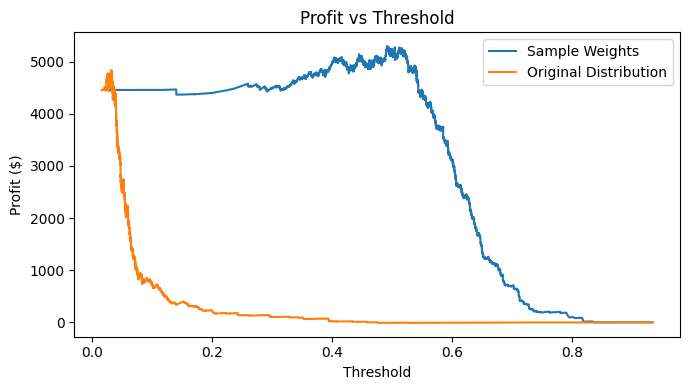

In [13]:
# Probabilities
probs_sw = gbm_sw.predict_proba(X_test)[:, 1]
probs_ci = gbm_ci.predict_proba(X_test)[:, 1]

# Profit across thresholds
thresholds = np.unique(np.concatenate([probs_sw, probs_ci]))
profits_sw = [compute_profit(probs_sw >= t, yd_test) for t in thresholds]
profits_ci = [compute_profit(probs_ci >= t, yd_test) for t in thresholds]

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, profits_sw, label='Sample Weights')
ax.plot(thresholds, profits_ci, label='Original Distribution')
ax.set_xlabel('Threshold')
ax.set_ylabel('Profit ($)')
ax.set_title('Profit vs Threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../../mlid-book/resources/ch4/ch4-fig3.png', dpi=300, bbox_inches='tight')
plt.show()

## TunedThresholdClassifierCV

Scikit-learn’s `TunedThresholdClassifierCV` can optimise the decision threshold by training the model on each cross-validation fold and tuning the threshold on the corresponding held-out fold.

We pass TARGET_D into the scorer via scikit-learn’s **metadata routing**, allowing the scorer to compute profit directly from the binary mailing decisions. The procedure then selects the threshold that maximises this profit metric.

In [14]:
from sklearn import set_config
from sklearn.model_selection import TunedThresholdClassifierCV 

# enable metadata routing
set_config(enable_metadata_routing=True)

# we need a sklearn compatible scoring function
def profit_score(y_true, y_pred, donations):
    return compute_profit(y_pred, donations)

# we nee to let the scorer know that it needs to request
# the donations vector
profit_scorer = (
    make_scorer(profit_score, response_method='predict')
    .set_score_request(donations=True)
)

# train model and optimise threshold for profit
# (it trains on the original distribution and adjusts the threshold)
gbm_profit = TunedThresholdClassifierCV(
    estimator = clone(pipe),
    scoring = profit_scorer, 
    cv = 3, 
    store_cv_results = True,
)
gbm_profit.fit(X_train, y_train, donations=yd_train)

,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",Pipeline(step...m_state=42))])
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",make_scorer(p...hod='predict')
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",3
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",True
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of

In [15]:
gbm_profit.best_score_, gbm_profit.best_threshold_

(np.float64(2331.5396230427145), np.float64(0.03222135623580411))

### Evalaute model with bootstrap

In [16]:
# model on original class distribution
profit, profit_std = evaluate_model_on_test_set(
    gbm_profit, 
    X_test, 
    yd_test, 
    tune_thresh=False, # TunedThreshCV predict() method uses the optimised threshold
)

print(f"profit=${profit:,.2f} ± {profit_std:.4f}")

model=original distr  profit=$3,315.25 ± 790.0346


This implementation is equivalent to our custom thresholding approach. As shown, the resulting profit distributions are very similar. `TunedThresholdClassifierCV` evaluates a smaller set of threshold candidates than our implementation, which explains the smoother, less noisy profile.